# Propensity Score Matching Step-By-Step

Finds statistical *twins* for an A/B test using Propensity Scores.

## Imports

In [7]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## Dataset Generation

In [65]:
# Generate a sample dataset
np.random.seed(42) # for reproducibility
n_samples = 1000

data = {
    'age': np.random.randint(18, 70, n_samples),
    'past_spend': np.random.rand(n_samples) * 1000 + 50,
    'is_mobile': np.random.choice([0, 1], n_samples, p=[0.6, 0.4]),
    'saw_ad': np.random.choice([0, 1], n_samples, p=[0.5, 0.5]) # Treatment variable
}

# Introduce some correlation between covariates and treatment for more realistic PSM
# For example, older users and mobile users might be slightly more likely to see the ad
for i in range(n_samples):
    if data['age'][i] > 45 and data['is_mobile'][i] == 1:
        if np.random.rand() < 0.65: # 65% chance to see ad
            data['saw_ad'][i] = 1
        else:
            data['saw_ad'][i] = 0
    elif data['is_mobile'][i] == 1:
        if np.random.rand() < 0.55: # 55% chance to see ad
            data['saw_ad'][i] = 1
        else:
            data['saw_ad'][i] = 0

df = pd.DataFrame(data)

In [66]:
# View
df.sample(4)

,age,past_spend,is_mobile,saw_ad
631,65,529.938835,1,0
233,49,996.115462,1,0
238,61,75.386356,1,0
234,50,423.309316,1,0


## Calculate The Propensity Scores

In [67]:
# Step 1: Calculate the Propensity Scores

# Define covariates and treament
covariates = ['age', 'past_spend', 'is_mobile']
treatment_col = 'saw_ad'

# 1. Estimate Propensity Scores (Probability of treatment)
lr = LogisticRegression()
X = df[covariates]
y = df[treatment_col]

# Fit a Logistic Regression
lr.fit(X, y)

# Store the probability of being in the 'Treatment' group
df['pscore'] = lr.predict_proba(X)[:, 1]

We added the propensity score (probability that the observation would be in the treatment group).

* Observation 588 would not be in the group who saw the advertising because it's under 50%,
* Observation 664 would.

In [85]:
df.loc[[588, 664]]

,age,past_spend,is_mobile,saw_ad,pscore
588,27,469.727317,0,0,0.476799
664,31,81.586145,1,1,0.597078


In [87]:
# 2. Split into Treatment and Control
treated = df[df[treatment_col] == 1].copy()
control = df[df[treatment_col] == 0].copy()

## Find the Statistical Twin

In [88]:
# 3. Use Nearest Neighbors to find matches
# We use a 'caliper' to ensure matches aren't too far apart
caliper = 0.05
nn = NearestNeighbors(n_neighbors=1, radius=caliper)
nn.fit(control[['pscore', 'age']])

# Find the matching pairs
distances, indices = nn.kneighbors(treated[['pscore', 'age']])

## Quality Control (Calibration)

In [89]:
# 4. Filter out matches that are outside our 'caliper' (quality control)
matched_control_idx = [control.index[i[0]] for d, i in zip(distances, indices) if d[0] <= caliper]
matched_treated_idx = [treated.index[i] for i, d in enumerate(distances) if d[0] <= caliper]

# Combine the matched pairs into a new balanced dataframe
matched_df = pd.concat([df.loc[matched_treated_idx], df.loc[matched_control_idx]])

In [104]:
matched_df.loc[[588, 664]]

,age,past_spend,is_mobile,saw_ad,pscore
588,27,469.727317,0,0,0.476799
588,27,469.727317,0,0,0.476799
664,31,81.586145,1,1,0.597078


In [105]:
df.shape

(1000, 5)

In [106]:
matched_df.shape

(1064, 5)

In [112]:
print(matched_df.saw_ad.value_counts())

saw_ad
1    532
0    532
Name: count, dtype: int64


## Evaluation of our PSM Model

In [114]:
# Check standard deviation (variance around the mean) of the Propensity Score
matched_df[['pscore']].describe().T

,count,mean,std,min,25%,50%,75%,max
pscore,1064.0,0.549428,0.058234,0.431018,0.501267,0.547584,0.598951,0.667701


### Standardized Mean Differences (SMD) for Covariates After Matching

To compare the means of other covariates like `age` and `is_mobile` after Propensity Score Matching, we can refer to the Standardized Mean Differences (SMD). A small SMD (typically below 0.1 or 0.05) indicates that the means of the covariate are well-balanced between the treated and control groups, suggesting successful matching.

In [115]:
def calculate_smd(df, covariate, treatment_col):
    treated_group = df[df[treatment_col] == 1][covariate]
    control_group = df[df[treatment_col] == 0][covariate]

    mean_treated = treated_group.mean()
    mean_control = control_group.mean()
    std_treated = treated_group.std()
    std_control = control_group.std()

    # Pooled standard deviation
    pooled_std = np.sqrt((std_treated**2 + std_control**2) / 2)

    if pooled_std == 0:
        return 0 # Avoid division by zero if there's no variance
    else:
        return (mean_treated - mean_control) / pooled_std

# Calculate SMD for each covariate
smd_results = {}
for cov in covariates:
    smd_results[cov] = calculate_smd(matched_df, cov, treatment_col)

smd_df = pd.DataFrame.from_dict(smd_results, orient='index', columns=['SMD'])
display(smd_df)

,SMD
age,0.000000
past_spend,0.049338
is_mobile,0.000000


In [116]:
display(smd_df)

# Interpretation of SMD values
for index, row in smd_df.iterrows():
    smd_value = row['SMD']
    interpretation = "well-balanced (excellent)" if abs(smd_value) < 0.05 else \
                     "reasonably balanced (good)" if abs(smd_value) < 0.1 else \
                     "moderately balanced" if abs(smd_value) < 0.2 else \
                     "poorly balanced"
    print(f"The covariate '{index}' has an SMD of {smd_value:.4f}, indicating it is {interpretation}.")

,SMD
age,0.000000
past_spend,0.049338
is_mobile,0.000000


The covariate 'age' has an SMD of 0.0000, indicating it is well-balanced (excellent).
The covariate 'past_spend' has an SMD of 0.0493, indicating it is well-balanced (excellent).
The covariate 'is_mobile' has an SMD of 0.0000, indicating it is well-balanced (excellent).


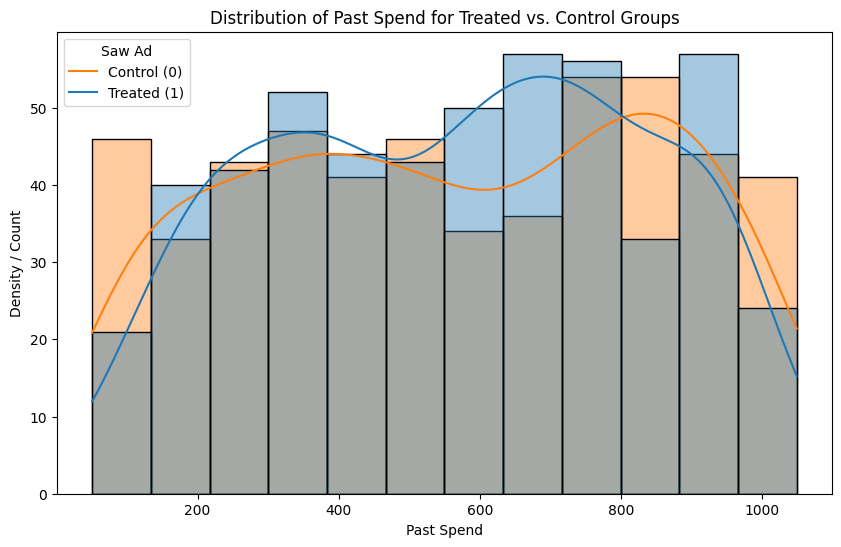

In [24]:
# Control and Treatment Distribution Overlays
plt.figure(figsize=(10, 6))
sns.histplot(data=matched_df, x='past_spend', hue='saw_ad', kde=True, alpha=.4)
plt.title('Distribution of Past Spend for Treated vs. Control Groups')
plt.xlabel('Past Spend')
plt.ylabel('Density / Count')
plt.legend(title='Saw Ad', labels=['Control (0)', 'Treated (1)'])
plt.show()

## Causal Inference Results

In [121]:
# Difference of averages
avg_past_spend_treated = matched_df[matched_df['saw_ad'] == 1]['past_spend'].mean()
avg_past_spend_control = matched_df[matched_df['saw_ad'] == 0]['past_spend'].mean()

past_spend_difference = avg_past_spend_treated - avg_past_spend_control

print(f"Average past_spend (Treated): {avg_past_spend_treated:.2f}")
print(f"Average past_spend (Control): {avg_past_spend_control:.2f}")
print(f"Difference in average past_spend: {past_spend_difference:.2f}")

Average past_spend (Treated): 541.97
Average past_spend (Control): 528.14
Difference in average past_spend: 13.82


In [133]:
matched_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1064.0,44.907895,14.874861,18.000000,33.000000,46.000000,57.000000,69.000000
past_spend,1064.0,535.054834,280.075942,54.939981,285.698368,529.938835,765.824965,1049.413726
is_mobile,1064.0,0.437970,0.496371,0.000000,0.000000,0.000000,1.000000,1.000000
saw_ad,1064.0,0.500000,0.500235,0.000000,0.000000,0.500000,1.000000,1.000000
pscore,1064.0,0.549428,0.058234,0.431018,0.501267,0.547584,0.598951,0.667701


In [123]:
# T-Test
treated_spend = matched_df[matched_df['saw_ad'] == 1]['past_spend']
control_spend = matched_df[matched_df['saw_ad'] == 0]['past_spend']

t_stat, p_value = stats.ttest_ind(treated_spend, control_spend, equal_var=False)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.3f}")

if p_value < 0.05:
    print("The difference in past_spend between treated and control groups is statistically significant (p < 0.05).")
else:
    print("The difference in past_spend between treated and control groups is NOT statistically significant (p >= 0.05).")

T-statistic: 0.805
P-value: 0.421
The difference in past_spend between treated and control groups is NOT statistically significant (p >= 0.05).


In [124]:
# Cohen's D Effect measurement

def cohens_d(df, outcome_col, treatment_col):
    treated_group = df[df[treatment_col] == 1][outcome_col]
    control_group = df[df[treatment_col] == 0][outcome_col]

    mean1, std1 = treated_group.mean(), treated_group.std()
    mean2, std2 = control_group.mean(), control_group.std()
    n1, n2 = len(treated_group), len(control_group)

    # Pooled standard deviation
    s_pooled = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))

    if s_pooled == 0:
        return 0 # Avoid division by zero
    else:
        return (mean1 - mean2) / s_pooled

# Calculate Cohen's d for 'past_spend'
d_value = cohens_d(matched_df, 'past_spend', 'saw_ad')

print(f"Cohen's d for past_spend: {d_value:.3f}")

# Interpret Cohen's d
if abs(d_value) < 0.2:
    interpretation = "negligible effect"
elif abs(d_value) < 0.5:
    interpretation = "small effect"
elif abs(d_value) < 0.8:
    interpretation = "medium effect"
else:
    interpretation = "large effect"

print(f"This indicates a {interpretation}.")

Cohen's d for past_spend: 0.049
This indicates a negligible effect.


## See the Matched Pairs

In [119]:
# Reconstruct the matched pairs to see which treated unit was matched to which control unit

# Create a list to store the matched pairs and their p-scores
matched_pairs_list = []

# Iterate through the treated units that found a match within the caliper
# We use the original indices from 'treated' and 'control' DataFrames
for i, treated_original_idx in enumerate(treated.index):
    # Check if this treated unit was part of the successful matches
    if treated_original_idx in matched_treated_idx:
        # Find its corresponding control match
        # The position of treated_original_idx in matched_treated_idx
        # corresponds to the position of its control match in matched_control_idx
        try:
            pos_in_matched_treated = matched_treated_idx.index(treated_original_idx)
            control_original_idx = matched_control_idx[pos_in_matched_treated]

            # Get propensity scores for the pair
            pscore_treated = df.loc[treated_original_idx, 'pscore']
            pscore_control = df.loc[control_original_idx, 'pscore']

            matched_pairs_list.append({
                'treated_original_index': treated_original_idx,
                'control_original_index': control_original_idx,
                'pscore_treated': pscore_treated,
                'pscore_control': pscore_control,
                'pscore_difference': abs(pscore_treated - pscore_control)
            })
        except ValueError: # Should not happen if matched_treated_idx and matched_control_idx are consistent
            pass

# Convert the list of dicts to a DataFrame
matched_pairs_df = pd.DataFrame(matched_pairs_list)

display(matched_pairs_df.head())
print(f"Total matched pairs found: {len(matched_pairs_df)}")


,treated_original_index,control_original_index,pscore_treated,pscore_control,pscore_difference
0,0,880,0.529479,0.523449,0.006030
1,1,453,0.570615,0.571172,0.000557
2,3,151,0.581419,0.580210,0.001208
3,6,361,0.510001,0.513928,0.003927
4,7,710,0.630256,0.629351,0.000905


Total matched pairs found: 532


In [120]:
# Add covariate values for treated and control units to matched_pairs_df
for cov in covariates:
    matched_pairs_df[f'{cov}_treated'] = df.loc[matched_pairs_df['treated_original_index'], cov].values
    matched_pairs_df[f'{cov}_control'] = df.loc[matched_pairs_df['control_original_index'], cov].values

# Display the updated DataFrame
display(matched_pairs_df.sample(5))

,treated_original_index,control_original_index,pscore_treated,pscore_control,pscore_difference,age_treated,age_control,past_spend_treated,past_spend_control,is_mobile_treated,is_mobile_control
490,900,905,0.595341,0.599103,0.003762,34,34,231.149350,156.876923,1,1
467,861,933,0.553131,0.553741,0.000610,20,20,513.494044,501.767679,1,1
364,682,622,0.500651,0.501568,0.000917,30,30,131.629982,114.208937,0,0
69,119,715,0.607085,0.617848,0.010763,56,56,844.025189,628.675409,1,1
299,549,306,0.554478,0.569292,0.014815,33,33,987.228487,701.420388,1,1


# Function

In [ ]:
def get_psm_matches(df, treatment_col, covariates, caliper=0.05):
    """
    Finds statistical twins for an A/B test using Propensity Scores.
    """
    # 1. Estimate Propensity Scores (Probability of treatment)
    lr = LogisticRegression()
    X = df[covariates]
    y = df[treatment_col]
    lr.fit(X, y)

    # Store the probability of being in the 'Treatment' group
    df['pscore'] = lr.predict_proba(X)[:, 1]

    # 2. Split into Treatment and Control
    treated = df[df[treatment_col] == 1].copy()
    control = df[df[treatment_col] == 0].copy()

    # 3. Use Nearest Neighbors to find matches
    # We use a 'caliper' to ensure matches aren't too far apart
    nn = NearestNeighbors(n_neighbors=1, radius=caliper)
    nn.fit(control[['pscore']])

    distances, indices = nn.kneighbors(treated[['pscore']])

    # 4. Filter out matches that are outside our 'caliper' (quality control)
    matched_control_idx = [control.index[i[0]] for d, i in zip(distances, indices) if d[0] <= caliper]
    matched_treated_idx = [treated.index[i] for i, d in enumerate(distances) if d[0] <= caliper]

    # Combine the matched pairs into a new balanced dataframe
    matched_df = pd.concat([df.loc[matched_treated_idx], df.loc[matched_control_idx]])
    return matched_df

In [ ]:
# Example usage:
df = df_sample
balanced_data = get_psm_matches(df, 'saw_ad', ['age', 'past_spend', 'is_mobile'])